In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

# Caminho relativo (funciona de qualquer lugar)
# data_path = Path("..") / "data" / "raw" / "gaussianas.csv"
# df = pd.read_csv(data_path)

In [ ]:
def plot_grid(data, labels):
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

    ax1 = fig.add_subplot(gs[0, :])  # ocupa as 2 colunas (gráfico 1)
    ax2 = fig.add_subplot(gs[1, 0])  # gráfico 2
    ax3 = fig.add_subplot(gs[1, 1])  # gráfico 3

    ax1.scatter(data[:, 0], data[:, 1], c=labels, cmap="viridis", edgecolor="k")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    ax1.set_title("Dados Gaussianos")
    ax1.grid()

    ax2.hist(data[labels == 0, 0], alpha=0.5, label="Classe 0")
    ax2.hist(data[labels == 1, 0], alpha=0.5, label="Classe 1")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("Frequência")
    ax2.set_title("Distribuição de x1 por Classe")
    ax2.legend()

    ax3.hist(data[labels == 0, 1], alpha=0.5, label="Classe 0")
    ax3.hist(data[labels == 1, 1], alpha=0.5, label="Classe 1")
    ax3.set_xlabel("x2")
    ax3.set_ylabel("Frequência")
    ax3.set_title("Distribuição de x2 por Classe")
    ax3.legend()

    plt.tight_layout()
    plt.show()


def gen_data(params: dict) -> np.ndarray:
    """Gera um DataFrame com duas classes de dados gaussianos."""

    mean1 = params["mean1"]
    mean2 = params["mean2"]
    cov1 = params["cov1"]
    cov2 = params["cov2"]
    priors = params["priors"]
    n_samples = params["n_samples"]
    seed = params["seed"]

    assert round(sum(priors), 2) == 1, "Os priors devem somar 1."

    class_1_pdf = multivariate_normal(mean1, cov1)
    class_2_pdf = multivariate_normal(mean2, cov2)

    class_1_samples = class_1_pdf.rvs(
        int(n_samples * priors[0]), random_state=seed + 15
    )
    class_2_samples = class_2_pdf.rvs(
        int(n_samples * priors[1]), random_state=seed + 35
    )

    data = np.vstack((class_1_samples, class_2_samples))
    labels = np.array([0] * len(class_1_samples) + [1] * len(class_2_samples))

    return data, labels


def get_posterior(params: dict, x):
    """Calcula a probabilidade a posteriori usando a distribuição normal multivariada."""
    prob_1 = multivariate_normal.pdf(x, mean=params["mean1"], cov=params["cov1"])
    prob_2 = multivariate_normal.pdf(x, mean=params["mean2"], cov=params["cov2"])
    priors = params["priors"]

    numerators = np.stack([prob_1 * priors[0], prob_2 * priors[1]], axis=1)
    return numerators / numerators.sum(axis=1, keepdims=True)


# Pensar no caso de 100 classes. Pensar na forma vetorial e broadcast.


def get_preds(x, params):

    posteriors = get_posterior(params, x)
    predicions = np.argmax(posteriors, axis=1)
    confidence = np.max(posteriors, axis=1)
    return predicions, confidence

    # Argmax da posterior
    # Func de confiança chow, rank de probabilidade.

Acurácia: 0.93


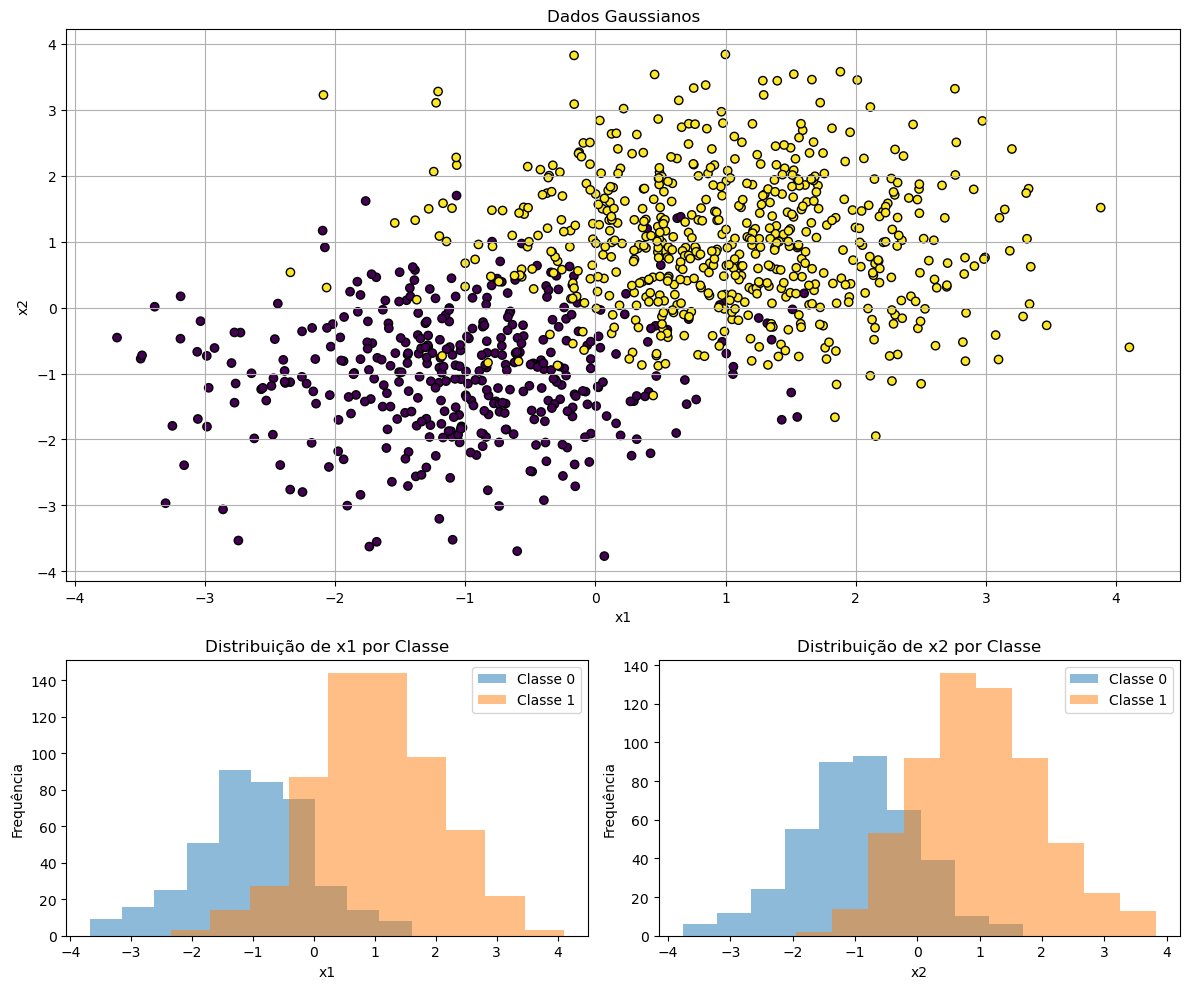

In [50]:
params = {
    "mean1": (-1, -1),
    "mean2": (1, 1),
    "cov1": [[1, 0], [0, 1]],
    "cov2": [[1, 0], [0, 1]],
    "priors": [0.4, 0.6],
    "n_samples": 1000,
    "seed": 77,
}

data, labels = gen_data(params)

classifications, confidence = get_preds(data, params)

# Analise do resultado

accuracy = np.mean(classifications == labels)
print(f"Acurácia: {accuracy:.2f}")

plot_grid(data, labels)

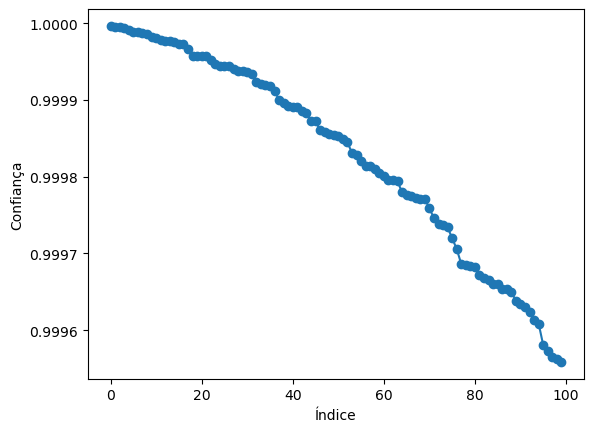

In [51]:
# plot RC curve.

# rank de probabilidade, func de confiança
index = np.argsort(confidence)[::-1]
sorted_confidence = confidence[index]
sorted_labels = labels[index]
sorted_predictions = classifications[index]
sorted_errors = sorted_predictions != sorted_labels

# teste de argsort
# display(sorted_confidence[:5])
plt.plot(sorted_confidence[:100], marker="o")
plt.xlabel("Índice")
plt.ylabel("Confiança")
plt.show()

In [52]:
coverages = np.linspace(0.2, 1, 10)

error_std = np.array([])
coberturas = np.array([])
bers = np.array([])
wgs = np.array([])
prevalence_1 = np.array([])
prevalence_2 = np.array([])


for k in coverages:
    # Cobertura
    index_k = int(k * len(sorted_labels))

    if (np.unique(sorted_labels[:index_k], return_counts=True)[1].min() > 5) & (
        len(np.unique(sorted_labels[:index_k])) == 2
    ):
        classes = np.unique(sorted_labels)

        # Selecionando os erros para a cobertura k
        errors_k = sorted_errors[:index_k]
        coberturas = np.append(coberturas, k)

        # error padrão da cobertura k
        error_rate_k = np.mean(errors_k)
        error_std = np.append(error_std, error_rate_k)

        # Erros por classe
        erros = [
            np.mean(sorted_errors[:index_k][sorted_labels[:index_k] == classe])
            for classe in classes
        ]

        # Erro Balanceado
        ber_k = np.mean(erros)
        bers = np.append(bers, ber_k)

        # Worst-group error
        wgs_k = np.max(erros)
        wgs = np.append(wgs, wgs_k)

        # Proporção das classes das classes
        prevalence_1 = np.append(
            prevalence_1, np.sum(sorted_labels[:index_k] == 0) / index_k
        )
        prevalence_2 = np.append(
            prevalence_2, np.sum(sorted_labels[:index_k] == 1) / index_k
        )

        assert np.isclose(
            prevalence_1[-1] + prevalence_2[-1], 1
        ), "A prevalência deve somar 1."

In [53]:
AURC_std = np.mean(error_std)
AURC_ber = np.mean(bers)
AURC_wgs = np.mean(wgs)

print(f"AURC (error padrão): {AURC_std:.4f}")
print(f"AURC (BER): {AURC_ber:.4f}")
print(f"AURC (WGS): {AURC_wgs:.4f}")

AURC (error padrão): 0.0170
AURC (BER): 0.0194
AURC (WGS): 0.0295


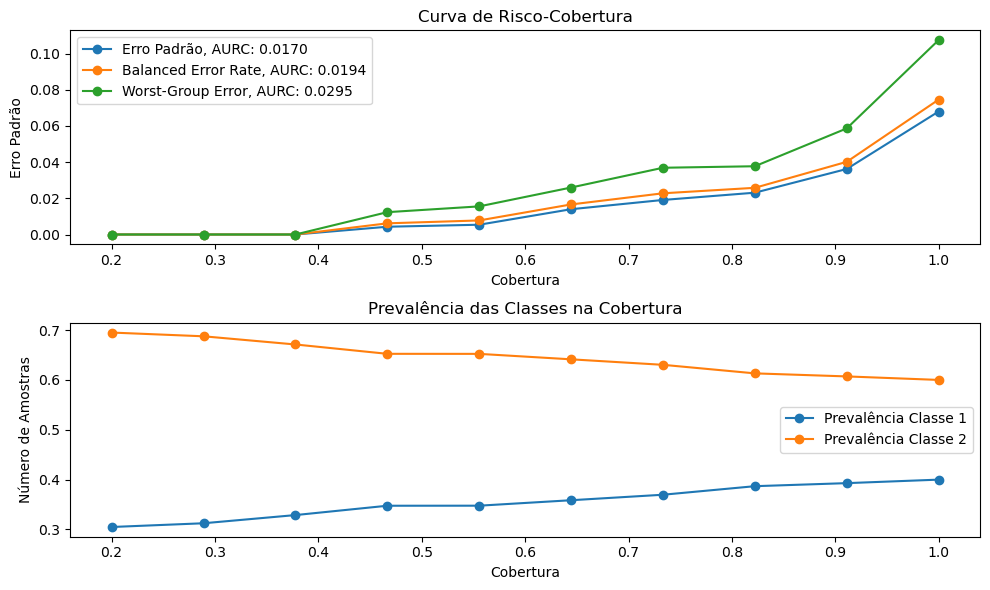

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].set_title("Curva de Risco-Cobertura")
axes[0].plot(
    coberturas,
    error_std,
    marker="o",
    label="Erro Padrão, AURC: {:.4f}".format(AURC_std),
)
axes[0].plot(
    coberturas,
    bers,
    marker="o",
    label="Balanced Error Rate, AURC: {:.4f}".format(AURC_ber),
)
axes[0].plot(
    coberturas,
    wgs,
    marker="o",
    label="Worst-Group Error, AURC: {:.4f}".format(AURC_wgs),
)
axes[0].set_xlabel("Cobertura")
axes[0].set_ylabel("Erro Padrão")
axes[0].legend()

axes[1].set_title("Prevalência das Classes na Cobertura")
axes[1].plot(coberturas, prevalence_1, marker="o", label="Prevalência Classe 1")
axes[1].plot(coberturas, prevalence_2, marker="o", label="Prevalência Classe 2")
axes[1].set_xlabel("Cobertura")
axes[1].set_ylabel("%\ de Amostras por classe")
axes[1].legend()

plt.tight_layout()
plt.show()